## Travelling Salesman Problem (TSP)


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
D = np.array(
    [
        [0, 20, 16, 25, 24],
        [20, 0, 12, 12, 27],
        [16, 12, 0, 10, 14],
        [25, 12, 10, 0, 20],
        [24, 27, 14, 20, 0],
    ]
)


In [3]:
graph = nx.Graph()
graph.add_nodes_from(range(D.shape[0]))
for i in range(D.shape[0]):
    for j in range(D.shape[0]):
        graph.add_edge(i, j, weight=D[i, j])


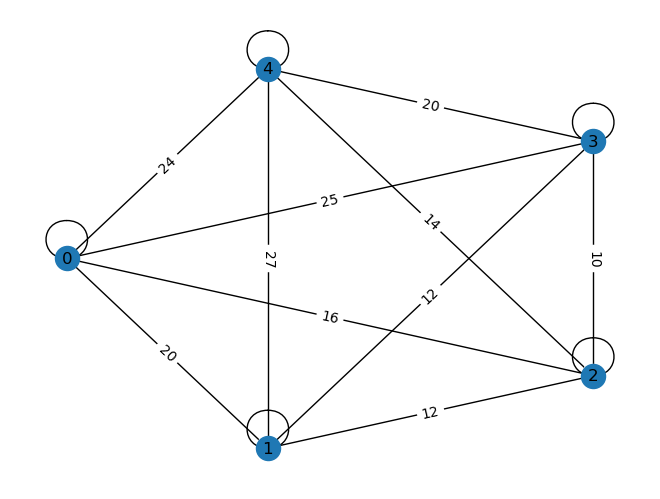

In [4]:
np.random.seed(2)
pos = nx.shell_layout(graph)
nx.draw(graph, pos, with_labels=True)
labels = nx.get_edge_attributes(graph, "weight")
nx.draw_networkx_edge_labels(graph, pos, edge_labels=labels)
plt.show()


### A brute force solution


In [5]:
from itertools import permutations

best_solution = [None, np.sum(D)]
for solution in list(permutations(range(1, D.shape[0]))):
    start, distance = (0, 0)
    for next_one in solution:
        distance += D[start, next_one]
        start = next_one
    distance += D[start, 0]
    if distance <= best_solution[1]:
        best_solution = [[0] + list(solution) + [0], distance]
        print("Best solution so far: %s kms" % str(best_solution)[1:-1])


Best solution so far: [0, 1, 2, 3, 4, 0], 86 kms
Best solution so far: [0, 1, 3, 2, 4, 0], 80 kms
Best solution so far: [0, 4, 2, 3, 1, 0], 80 kms


In [6]:
from scipy.special import perm

perm(13, 13) / 2


3113510400.0

### A dynamic programming solution


In [7]:
from itertools import combinations

memo = {
    (frozenset([0, idx + 1]), idx + 1): (dist, [0, idx + 1])
    for idx, dist in enumerate(D[0][1:])
}
cities = D.shape[0]
for subset_size in range(2, cities):
    # Here we define the size of the subset of cities
    new_memo = dict()
    for subset in [
        frozenset(comb) | {0} for comb in combinations(range(1, cities), subset_size)
    ]:
        # We enumerate the subsets having a certain subset
        # size
        for ending in subset - {0}:
            # We consider every ending point in the subset
            all_paths = list()
            for k in subset:
                # We check the shortest path for every
                # element in the subset
                if k != 0 and k != ending:
                    length = memo[(subset - {ending}, k)][0] + D[k][ending]
                    index = memo[(subset - {ending}, k)][1] + [ending]
                    all_paths.append((length, index))
            new_memo[(subset, ending)] = min(all_paths)
    # In order to save memory, we just record the previous
    # subsets since we won't use shorter ones anymore
    memo = new_memo
# Now we close the cycle and get back to the start of the
# tour, city zero
tours = list()
for distance, path in memo.values():
    distance += D[path[-1], 0]
    tours.append((distance, path + [0]))
# We can now declare the shortest tour
distance, path = min(tours)
print("Shortest dynamic programming tour is: %s, %i kms" % (path, distance))


Shortest dynamic programming tour is: [0, 1, 3, 2, 4, 0], 80 kms
